In [1]:
import numpy as np
import pandas as pd

from rate_model import RateModelWC
from resp_predictor_2 import ResponsePredictor_2

In [202]:
#np.random.seed(116)
np.random.seed(113)

# Model
N = 5  # Number of populations
W = 0.2 * np.random.randn(N, N)  # Weight matrix
model = RateModelWC(W, tau=1, rmax=10, gain_slope=0.5, gain_center=0)
model.sim_res_type = 'final'

# External input
h0 = 1 * np.random.randn(N, 1)

# Simulation params
dt, nsteps = 0.5, 20

pred = ResponsePredictor_2(model, h0, dt=dt, nsteps=nsteps)
pred.train(dh=0.1, dr=0.1)

print(np.round(pred.r0, 3).T)

[[4.335 9.418 5.56  4.753 3.753]]


In [203]:
dh_abs = 1

# Random input perturbation
Dh = np.random.random((N, 1)) * dh_abs

# Actual rate under perturbed input
r = model.run(h0 + Dh, pred.r0, dt, nsteps)

# Estimated rate under perturbed input
r_hat = pred.predict_r(Dh)
r_hat_0 = pred.predict_r(Dh, max_iter=0)   # no dr2 and drdh terms
r_hat_00 = pred.predict_r(Dh, max_iter=0, use_dh2=False)   # 1-st order

# Build and print the results table
df_result = pd.DataFrame({
    'pop': np.arange(N),
    'r': r.ravel(),
    'r_hat': r_hat.ravel(),
    'r_hat_0': r_hat_0.ravel(),
    'r_hat_00': r_hat_00.ravel(),
    'err': np.abs(r_hat.ravel() - r.ravel()),
    'err_0': np.abs(r_hat_0.ravel() - r.ravel()),
    'err_00': np.abs(r_hat_00.ravel() - r.ravel())
})
print(np.round(df_result, 3))

err = np.sqrt(np.mean((r_hat - r) ** 2))
err0 = np.sqrt(np.mean((r_hat_0 - r) ** 2))
err00 = np.sqrt(np.mean((r_hat_00 - r) ** 2))
print()
print(f"RMSE (full prediction):\t\t{err:.04f}")
print(f"RMSE (without dr2/drdh terms):\t{err0:.04f}")
print(f"RMSE (1st order prediction):\t{err00:.04f}")

   pop      r  r_hat  r_hat_0  r_hat_00    err  err_0  err_00
0    0  4.877  4.877    4.887     4.878  0.001  0.010   0.001
1    1  9.590  9.587    9.619     9.622  0.003  0.029   0.032
2    2  6.204  6.207    6.207     6.218  0.003  0.004   0.015
3    3  5.320  5.322    5.323     5.324  0.003  0.004   0.004
4    4  4.096  4.095    4.108     4.094  0.001  0.012   0.002

RMSE (full prediction):		0.0024
RMSE (without dr2/drdh terms):	0.0148
RMSE (1st order prediction):	0.0161


In [204]:
import xarray as xr

n_dh = 20       # number of dh_abs values to probe
n_trials = 50   # number of random trials for each dh_abs

dh_abs_vals = 10. ** np.linspace(-1.5, 2, n_dh)

R = xr.DataArray(
    np.full((N, n_dh, n_trials), np.nan),
    dims=['pop', 'dh_abs', 'trial'],
    coords={
        'pop': np.arange(N),
        'dh_abs': dh_abs_vals,
        'trial': np.arange(n_trials)
    }
)
Rhat = xr.DataArray(
    np.full((N, n_dh, n_trials, 3), np.nan),
    dims=['pop', 'dh_abs', 'trial', 'method'],
    coords={
        'pop': np.arange(N),
        'dh_abs': dh_abs_vals,
        'trial': np.arange(n_trials),
        'method': ['ord1', 'ord1_dh2', 'ord2']
    }
)

for n, dh_abs in enumerate(dh_abs_vals):
    for m in range(n_trials):        
        # Random input perturbation
        Dh = np.random.random((N, 1)) * dh_abs

        # Actual rate under perturbed input
        R.isel(dh_abs=n, trial=m)[...] = (
            model.run(h0 + Dh, pred.r0, dt, nsteps).ravel())

        # Estimated rate under perturbed input
        Rhat.isel(dh_abs=n, trial=m).loc[{'method': 'ord1'}] = (
            pred.predict_r(Dh, max_iter=0, use_dh2=False).ravel())
        Rhat.isel(dh_abs=n, trial=m).loc[{'method': 'ord1_dh2'}] = (
            pred.predict_r(Dh, max_iter=0).ravel())
        Rhat.isel(dh_abs=n, trial=m).loc[{'method': 'ord2'}] = (
            pred.predict_r(Dh).ravel())

(1, 50)

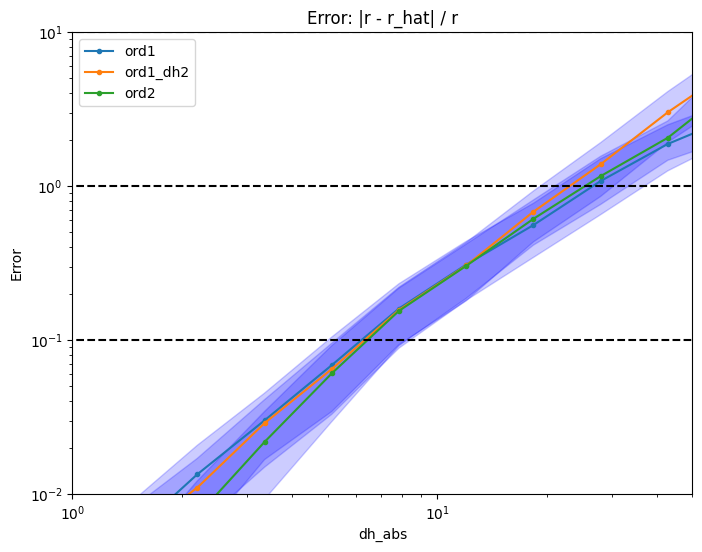

In [209]:
import matplotlib.pyplot as plt

# Compute error mean and std. over trials
err = (np.abs(R - Rhat) / R).mean(dim='pop')
#err = (np.abs(R - Rhat) / R).max(dim='pop')
#err = np.sqrt(((R - Rhat) ** 2).mean(dim='pop'))
#err = np.sqrt(((R - Rhat) ** 2).mean(dim='pop')) / R.mean(dim='pop')
err_mean = err.mean(dim='trial')
err_std = err.std(dim='trial')

#pop_vis = 0

# Plot mean error as a function of dh_abs
plt.figure(figsize=(8, 6))
for method in ['ord1', 'ord1_dh2', 'ord2']:
    err_mean_ = err_mean.sel({'method': method}).values
    err_std_ = err_std.sel({'method': method}).values
    plt.plot(dh_abs_vals, err_mean_, '.-', label=method)
    plt.fill_between(
        dh_abs_vals,
        err_mean_ - err_std_,
        err_mean_ + err_std_,
        color='blue',
        alpha=0.2
    )
for l in [0.1, 1, 10]:
    plt.plot([dh_abs_vals.min(), dh_abs_vals.max()], [l, l], 'k--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('dh_abs')
plt.ylabel('Error')
plt.title(f'Error: |r - r_hat| / r')
#plt.title(f'Error: rms(r - r_hat)')
plt.legend()
plt.ylim([0.01, 10])
plt.xlim([1, 50])

In [159]:
#err_mean_ = err_mean.sel(method=method).values.ravel()
err_std.sel({'method': 'ord1'})
#dh_abs_vals

<xarray.DataArray (dh_abs: 20)>
array([1.98156907e-07, 2.93548778e-07, 4.69060924e-07, 7.34272860e-07,
       1.42601609e-06, 3.00195105e-06, 2.89863182e-06, 9.51747214e-06,
       1.21285941e-05, 2.15879683e-05, 5.71833383e-05, 9.16769982e-05,
       1.42575058e-04, 2.88028917e-04, 1.05510322e-03, 2.28835046e-03,
       5.30520427e-03, 1.31657007e-02, 1.64242014e-02, 4.61381565e-02])
Coordinates:
  * dh_abs   (dh_abs) float64 0.003162 0.004549 0.006543 ... 1.528 2.198 3.162
    method   <U8 'ord1'

In [57]:
print(model.W)

[[ 0.08998852 -0.20317535  0.15442683 -0.24387289 -0.15632693]
 [ 0.11029579 -0.30729532 -0.10321183 -0.14965876  0.27636069]
 [ 0.14214165 -0.01654825  0.10124414 -0.31105034  0.26251435]
 [-0.11001834 -0.20376089  0.01572457 -0.13869047  0.11918928]
 [ 0.02415567  0.05435595 -0.22388493 -0.17226273  0.18017132]]


In [ ]:
# Explore eigenvalues of J2
L = np.zeros((N, N))
V = np.zeros((N, N))
for n in range(N):
    J2 = pred.J2[n, :, :]
    L[:, n], V_ = np.linalg.eig(J2)
    V[:, n] = V_[:, 0]
L /= L[0, :]
np.set_printoptions(formatter={'float': lambda x: f'{x:.02e}'})
#print(np.log(np.abs(L)))
print(L)
#print(V)

# Compare full and rank-1 J2 calculation
J20 = pred.J2
pred._calc_J2_estim(dr=0.1)
J2 = pred.J2
n = 3
np.max(np.abs(J20[n, :] - J2[n, :]).ravel()) / np.max(np.abs(J20[n, :]))